In [9]:
import pandas as pd

df = pd.read_csv('data/india_superstore.csv.csv', encoding='latin1')


In [10]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,IND-10000,2021-06-25,2021-06-28,Standard Class,Vivek Yadav,Corporate,Ahmedabad,Gujarat,Office Supplies,Binders,1535.72,4,0.3,292.37
1,IND-10001,2021-07-16,2021-07-18,Same Day,Ritu Gupta,Consumer,Kanpur,Uttar Pradesh,Furniture,Chairs,3502.72,6,0.3,200.70
2,IND-10002,2022-06-22,2022-06-26,Second Class,Kiran Verma,Home Office,Nashik,Maharashtra,Furniture,Chairs,2133.33,5,0.1,709.54
3,IND-10003,2022-05-18,2022-05-19,Second Class,Anjali Pandey,Consumer,NaN,West Bengal,Furniture,Chairs,2679.61,5,0.3,645.03
4,IND-10004,2022-08-03,2022-08-06,Second Class,Vikas Chatterjee,Home Office,Bhopal,Madhya Pradesh,Technology,Copiers,470.83,8,0.4,23.05


In [11]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer Name',
       'Segment', 'City', 'State', 'Category', 'Sub-Category', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

# Customer Name helps the business identify repeat customers, high-value customers, and understand customer purchasing behavior.

In [12]:
df['Customer Name']

0            Vivek Yadav
1             Ritu Gupta
2            Kiran Verma
3          Anjali Pandey
4       Vikas Chatterjee
              ...       
1995          Neha Gupta
1996    Priya Chatterjee
1997       Anjali Tiwari
1998        Kiran Saxena
1999      Manish Agarwal
Name: Customer Name, Length: 2000, dtype: object

# City helps identify high-performing and low-performing locations so the business can plan marketing, inventory, and expansion decisions.

In [13]:
df['City']

0       Ahmedabad
1          Kanpur
2          Nashik
3             NaN
4          Bhopal
          ...    
1995          NaN
1996    New Delhi
1997         Agra
1998       Mysuru
1999       Mysuru
Name: City, Length: 2000, dtype: object

# State helps the business evaluate regional performance, identify loss-making regions, and decide where to expand operations or optimize inventory distribution.

In [14]:
df['State']


0              Gujarat
1        Uttar Pradesh
2          Maharashtra
3          West Bengal
4       Madhya Pradesh
             ...      
1995    Madhya Pradesh
1996             Delhi
1997     Uttar Pradesh
1998         Karnataka
1999         Karnataka
Name: State, Length: 2000, dtype: object

# Category helps the business understand which product types perform well or poorly in terms of sales and profit, so the company can focus marketing, pricing, and inventory improvements on weak categories.

In [15]:
df['Category']

0       Office Supplies
1             Furniture
2             Furniture
3             Furniture
4            Technology
             ...       
1995         Technology
1996         Technology
1997    Office Supplies
1998         Technology
1999          Furniture
Name: Category, Length: 2000, dtype: object

# Sub-Category provides deeper product-level insight, helping the business identify which specific products within a category are profitable or loss-making.

In [16]:
df['Sub-Category']

0           Binders
1            Chairs
2            Chairs
3            Chairs
4           Copiers
           ...     
1995        Copiers
1996       Machines
1997         Labels
1998    Accessories
1999      Bookcases
Name: Sub-Category, Length: 2000, dtype: object

# Sales represents the revenue generated from a product before deducting any costs or expenses.

In [17]:
df['Sales']

0       1535.72
1       3502.72
2       2133.33
3       2679.61
4        470.83
         ...   
1995    4047.32
1996     355.77
1997     225.22
1998     2279.8
1999    2838.19
Name: Sales, Length: 2000, dtype: object

# Quantity tells how many units of a product were sold and helps the business understand product demand and inventory planning.

In [18]:
df['Quantity']

0       4
1       6
2       5
3       5
4       8
       ..
1995    7
1996    2
1997    8
1998    5
1999    4
Name: Quantity, Length: 2000, dtype: int64

# Discount helps analyze how price reductions affect sales and profit, and whether high discounts are causing losses.

In [19]:
df['Discount']

0       0.3
1       0.3
2       0.1
3       0.3
4       0.4
       ... 
1995    0.0
1996    0.2
1997    0.0
1998    0.4
1999    0.1
Name: Discount, Length: 2000, dtype: float64

# Data Quality Check

# Missing Value Analysis

In this step, we check whether the dataset contains any missing or invalid values that could affect the analysis.


In [20]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer Name    60
Segment           0
City             60
State             0
Category          0
Sub-Category      0
Sales             0
Quantity          0
Discount         40
Profit            0
dtype: int64

**Observation**

Missing values are present in the Customer Name and City columns.
Additionally, the Discount column contains invalid string values ("N/A"), which behave like missing data and need cleaning.


# Data Type Inspection


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       2000 non-null   object 
 1   Order Date     2000 non-null   object 
 2   Ship Date      2000 non-null   object 
 3   Ship Mode      2000 non-null   object 
 4   Customer Name  1940 non-null   object 
 5   Segment        2000 non-null   object 
 6   City           1940 non-null   object 
 7   State          2000 non-null   object 
 8   Category       2000 non-null   object 
 9   Sub-Category   2000 non-null   object 
 10  Sales          2000 non-null   object 
 11  Quantity       2000 non-null   int64  
 12  Discount       1960 non-null   float64
 13  Profit         2000 non-null   float64
dtypes: float64(2), int64(1), object(11)
memory usage: 218.9+ KB


- Order Date is stored as object instead of datetime.
- Sales is stored as object instead of numeric due to formatting issues.
- Discount is numeric but contains missing values (converted from "N/A").
- Order ID and Customer Name are correctly stored as object since they are identifiers/text fields.


# Duplicate Record Check

We check whether any transaction is recorded more than once, as duplicate records can lead to incorrect sales and profit calculations.


In [22]:
df.duplicated().sum()

0

**Observation**

No duplicate records were found in the dataset.  
This means each row represents a unique transaction and the data is safe to use for further analysis.


# Date Consistency Check

We verify whether the shipping date occurs after the order date. 
Shipping before ordering is logically impossible and indicates data entry errors.


In [23]:
(df['Ship Date'] < df['Order Date']).sum()

19

**Observation**

19 records were found where the Ship Date is earlier than the Order Date.  
These rows contain inconsistent data and need correction or removal before analysis.


# Handling Missing Customer Name
Customer Name values are missing in some records. 
Since the transaction still exists, dropping rows would remove valid sales data. 
Therefore, missing values will be replaced with "Unknown Customer".


In [24]:
df['Customer Name'] = df['Customer Name'].fillna('Unknown Customer')

# Verification

In [25]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer Name     0
Segment           0
City             60
State             0
Category          0
Sub-Category      0
Sales             0
Quantity          0
Discount         40
Profit            0
dtype: int64

**Result**

Missing Customer Name values have been replaced with a placeholder ("Unknown Customer").
The transactions were preserved because sales and profit information were valid.

This ensures revenue calculations remain accurate while still identifying records
where customer identity is unavailable.

# Handling Missing City Values
City represents geographical information used for location-based analysis. 
Filling incorrect city names could mislead business decisions. 
Therefore, rows with missing City values will be removed from the dataset.


In [26]:
df.dropna(subset=['City'],inplace=True)

# Verification

After removing missing City values, the dataset now contains only valid location records.
This ensures accurate state-wise and city-wise performance analysis.


In [27]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer Name     0
Segment           0
City              0
State             0
Category          0
Sub-Category      0
Sales             0
Quantity          0
Discount         39
Profit            0
dtype: int64

# Result:

Rows with missing City values have been removed from the dataset.
Since location-based analysis depends on accurate geographical information,
removing these records prevents misleading state-wise and city-wise insights.

The dataset now contains only valid location entries and is reliable for regional sales analysis.


# Handling Missing Discount Values

The Discount column has missing values.
Since Sales and Profit values are available, the transactions are valid.

In retail data, missing discount typically indicates that no discount was applied.
Therefore, missing values will be treated as 0 (No Discount) instead of removing rows.


In [28]:
df['Discount'] = df['Discount'].fillna(0)

# Verification

In [29]:
df['Discount'].isnull().sum()

0

# Result:

Missing values in the Discount column have been replaced with 0, assuming no discount was applied to those transactions.

This approach preserves valid sales records and ensures accurate profit margin and pricing analysis without introducing artificial discount values.


Business Overview

Key Business Metrics

To understand overall business performance, we calculate total sales, total profit, and total number of orders.

In [30]:
df['Profit'].sum()

739962.5599999999

In [31]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,IND-10000,2021-06-25,2021-06-28,Standard Class,Vivek Yadav,Corporate,Ahmedabad,Gujarat,Office Supplies,Binders,1535.72,4,0.3,292.37
1,IND-10001,2021-07-16,2021-07-18,Same Day,Ritu Gupta,Consumer,Kanpur,Uttar Pradesh,Furniture,Chairs,3502.72,6,0.3,200.70
2,IND-10002,2022-06-22,2022-06-26,Second Class,Kiran Verma,Home Office,Nashik,Maharashtra,Furniture,Chairs,2133.33,5,0.1,709.54
4,IND-10004,2022-08-03,2022-08-06,Second Class,Vikas Chatterjee,Home Office,Bhopal,Madhya Pradesh,Technology,Copiers,470.83,8,0.4,23.05
5,IND-10005,2021-07-31,2021-08-03,Standard Class,Nitin Kumar,Corporate,Coimbatore,Tamil Nadu,Furniture,Chairs,4657.42,9,0.2,472.54


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1940 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       1940 non-null   object 
 1   Order Date     1940 non-null   object 
 2   Ship Date      1940 non-null   object 
 3   Ship Mode      1940 non-null   object 
 4   Customer Name  1940 non-null   object 
 5   Segment        1940 non-null   object 
 6   City           1940 non-null   object 
 7   State          1940 non-null   object 
 8   Category       1940 non-null   object 
 9   Sub-Category   1940 non-null   object 
 10  Sales          1940 non-null   object 
 11  Quantity       1940 non-null   int64  
 12  Discount       1940 non-null   float64
 13  Profit         1940 non-null   float64
dtypes: float64(2), int64(1), object(11)
memory usage: 227.3+ KB


In [33]:
df['Sales'].unique()

array(['1535.72', '3502.72', '2133.33', ..., '225.22', '2279.8',
       '2838.19'], dtype=object)

# Cleaning Sales Column

The Sales column contains numeric values stored as text due to formatting commas.
The commas will be removed to make the values machine-readable before converting the column to float datatype.



In [34]:
df['Sales'] = df['Sales'].str.replace(',' , "")

In [35]:
df['Sales'] = df['Sales'].astype(float)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1940 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       1940 non-null   object 
 1   Order Date     1940 non-null   object 
 2   Ship Date      1940 non-null   object 
 3   Ship Mode      1940 non-null   object 
 4   Customer Name  1940 non-null   object 
 5   Segment        1940 non-null   object 
 6   City           1940 non-null   object 
 7   State          1940 non-null   object 
 8   Category       1940 non-null   object 
 9   Sub-Category   1940 non-null   object 
 10  Sales          1940 non-null   float64
 11  Quantity       1940 non-null   int64  
 12  Discount       1940 non-null   float64
 13  Profit         1940 non-null   float64
dtypes: float64(3), int64(1), object(10)
memory usage: 227.3+ KB


# Result & Verification

The Sales column has been successfully converted from text format to numeric format (float64).

Previously, the column contained commas (,) which caused pandas to treat it as an object datatype. 
After removing the commas and converting the datatype, the column can now be used for mathematical operations such as total revenue, averages, and profit analysis.


In [37]:
df['Sales'].sum()

5030550.880000001

In [38]:
df['Profit'] / df['Sales'] * 100

0       19.037976
1        5.729833
2       33.259739
4        4.895610
5       10.145961
          ...    
1994    23.365112
1996     2.124968
1997    34.615043
1998     4.322309
1999    27.714494
Length: 1940, dtype: float64

Profit Margin Analysis

Purpose

To evaluate the overall financial health of the company, we calculate the profit margin.
Profit margin helps us understand how much profit the company keeps from its total sales.

In [39]:
total_profit = df['Profit'].sum()

In [40]:
total_sales = df['Sales'].sum()

In [41]:
profit_margin = total_profit / total_sales * 100
profit_margin

14.70937433396956

Result

The overall profit margin of the superstore is approximately 14.7%.

# Category-wise Business Performance Analysis

In this section, we analyze sales and profit for each product category to understand which categories contribute positively to the business and which are causing losses.


In [42]:
df['Category'] = df['Category'].astype(str)

In [43]:
df['Category'] = df['Category'].str.lower()

In [44]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
office supplies    1765201.03
technology         1656431.24
furniture          1608918.61
Name: Sales, dtype: float64

# Key Observations

- Office Supplies generates the highest total sales among all categories.
- Technology follows closely and also shows strong business performance.
- Furniture records comparatively lower sales than the other categories.

In [45]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
office supplies    263981.94
technology         238764.23
furniture          237216.39
Name: Profit, dtype: float64

# Profitability Insights

- Office Supplies contributes the highest profit to the company.
- Technology also produces significant profit and remains a strong performing category.
- Furniture generates comparatively lower profit despite considerable sales.

# Furniture Sub-Category Analysis

After identifying weaker performance in the Furniture category, a deeper analysis was performed at the sub-category level to determine which specific products were affecting profitability.

The objective is to check whether the issue lies with the entire category or with particular products.


In [46]:
total_pro = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

In [47]:
total_sale = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

# Profit Margin Calculation

To measure performance accurately, profit margin is calculated for each sub-category using:

Profit Margin = (Total Profit / Total Sales) × 100

Profit margin helps evaluate efficiency instead of just total profit, since a product can generate high revenue but still perform poorly if margins are low.


In [48]:
profit_mar = (total_pro / total_sale * 100).sort_values(ascending=False)

# Key Findings

- Chairs have the highest profit margin, indicating strong pricing and demand.
- Other products maintain moderate margins.
- Bookcases show one of the lowest profit margins.

This indicates that the issue is not the Furniture category overall, but specifically the Bookcases product line.


In [49]:
profit_mar

Sub-Category
Chairs         16.601159
Binders        15.645155
Paper          15.553415
Art            15.484257
Tables         15.286792
Accessories    14.932038
Machines       14.890369
Copiers        14.391454
Storage        14.370823
Furnishings    13.980225
Labels         13.655671
Phones         13.399451
Bookcases      12.993178
dtype: float64

# Business Interpretation

The company appears to be offering higher discounts or incurring higher operational costs to sell Bookcases.

Despite generating sales, Bookcases contribute less profit compared to other furniture products, making them an underperforming product in terms of efficiency.


# Recommendation

To improve profitability, the company should:

- Review discount strategy for Bookcases
- Adjust pricing where possible
- Optimize shipping and handling costs
- Bundle Bookcases with high-performing products like Chairs

Improving Bookcases performance can significantly improve overall Furniture category profitability.


# Discount Analysis (Furniture Category)

Since Bookcases showed low profitability, the next step is to investigate whether pricing strategy is affecting margins.

One common reason for low margin products in retail is excessive discounting. Therefore, average discount offered on each furniture sub-category is analyzed.


In [50]:
furniture = df[df['Category'] == 'furniture']

# Average Discount by Sub-Category

To verify the pricing hypothesis, the average discount for each furniture sub-category is calculated.

Higher discount values indicate that the company is reducing selling price aggressively to drive sales.


In [51]:
furniture.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

Sub-Category
Furnishings    0.198137
Bookcases      0.196429
Chairs         0.188079
Tables         0.170701
Name: Discount, dtype: float64

# Findings

- Bookcases receive one of the highest average discounts among furniture products.
- Chairs, despite better performance, receive lower discounts.
- Tables receive the lowest discount levels.

This shows that the company is trying to push Bookcases sales by offering heavier discounts.


# Business Insight

Even after offering higher discounts, Bookcases still generate lower profit margins and lower sales compared to other furniture products.

This indicates a demand problem rather than just a pricing problem. The product is not naturally attractive to customers, and discounting alone is not improving performance.

In business terms, Bookcases represent a low-efficiency product where revenue is being generated at the cost of profitability.


### Recommendation

Instead of increasing discounts further, the company should:

- Reposition the product in the market
- Improve product design or quality
- Bundle Bookcases with complementary items (e.g., study tables or chairs)
- Reduce inventory exposure

Continuing heavy discounting may increase sales temporarily but will continue to hurt long-term profitability.


# Sales Contribution by Furniture Sub-Categories

To understand whether Bookcases suffer from low demand, total sales for each furniture sub-category are analyzed.

Sales helps determine product popularity and customer demand.


In [52]:
furniture.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Furnishings    436553.34
Tables         415991.26
Chairs         396801.09
Bookcases      359572.92
Name: Sales, dtype: float64

# Sales Observations

- Furnishings generate the highest sales.
- Tables and Chairs follow with strong sales performance.
- Bookcases record the lowest total sales within the Furniture category.

This indicates that Bookcases have weaker demand compared to other furniture products.


# Profit Contribution by Furniture Sub-Categories

After analyzing demand through sales, profit contribution is examined to understand actual business value generated by each product type.

Profit is the most important metric because it directly affects company sustainability.


In [53]:
furniture.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

Sub-Category
Chairs         65873.58
Tables         63591.72
Furnishings    61031.14
Bookcases      46719.95
Name: Profit, dtype: float64

# Profit Observations

- Chairs generate the highest profit among furniture products.
- Tables and Furnishings also contribute significantly.
- Bookcases produce the lowest profit.

Although Bookcases are not loss-making, their contribution to overall business profit is minimal.


# Order-Level Profit Analysis (Bookcases)

To understand whether Bookcases are consistently underperforming or affected by specific transactions, order-level profit distribution is analyzed.

Instead of looking at total profit, individual order profits are examined.


In [54]:
furniture[furniture["Sub-Category"]=="Bookcases"]["Profit"].describe()


count     140.000000
mean      333.713929
std       339.078370
min      -209.540000
25%        83.177500
50%       228.920000
75%       539.517500
max      1409.200000
Name: Profit, dtype: float64

# Root Cause Identified

The primary issue with Bookcases is not lack of demand but inconsistent discount strategy.

Certain transactions are being sold at very high discounts, occasionally below cost price. These loss-making orders significantly reduce the overall profitability of the Furniture category.


# Key Observations

- Some Bookcases orders generate very high profit.
- However, certain orders generate negative profit (loss-making sales).
- The large variation in profit indicates inconsistent pricing or discounting.

This means the product itself is not inherently unprofitable, but certain transactions are harming overall profitability.


# Final Business Insight

The low margin of Bookcases is primarily driven by heavy discounting in specific orders rather than poor product demand.

The company is occasionally selling Bookcases below cost, which reduces overall category profitability.

Controlling discount policies for Bookcases could significantly improve profit without needing to increase sales volume.


In [55]:
bookcases = furniture[furniture["Sub-Category"] == "Bookcases"]




In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

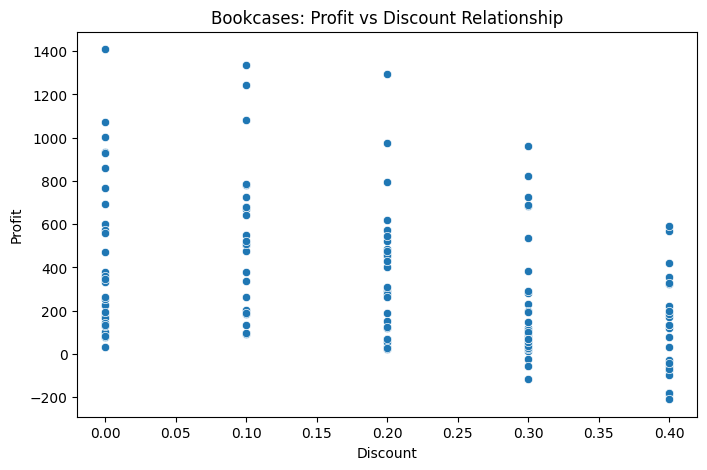

In [57]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=bookcases, x = 'Discount', y = 'Profit')
plt.title("Bookcases: Profit vs Discount Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.savefig('profit_discount.png')

plt.show()


# Visual Insight: Profit vs Discount

The scatter plot shows a clear negative relationship between discount and profit.

At low discount levels, most orders are profitable. However, as discount increases, profit decreases and several orders become loss-making.

This visually confirms that high discounting is the primary driver of low profitability in Bookcases.


In [58]:
discount_profit = (
    bookcases
    .groupby('Discount')['Profit']
    .mean()
    .reset_index()
)
discount_profit

,Discount,Profit
0,0.0,437.760968
1,0.1,526.133200
2,0.2,375.464286
3,0.3,227.625000
4,0.4,102.087692


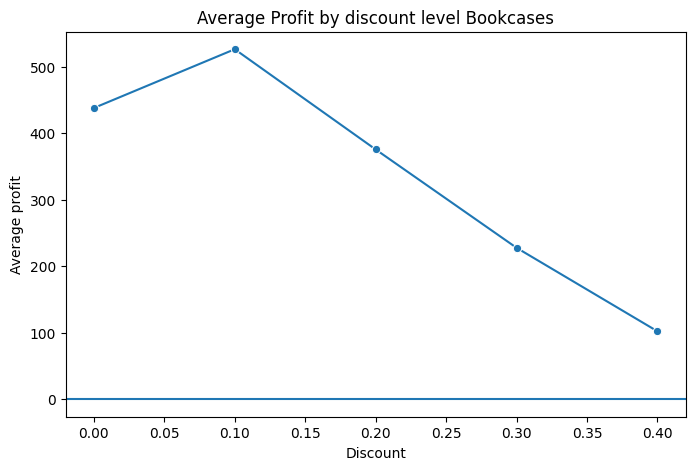

In [59]:
plt.figure(figsize=(8,5))
sns.lineplot(data=discount_profit, x = 'Discount', y = 'Profit', marker='o')
plt.title('Average Profit by discount level Bookcases')
plt.xlabel('Discount')
plt.ylabel('Average profit')
plt.axhline(0)
plt.savefig('profit_threshold.png')
plt.show()

# Discount Threshold Insight

The line chart shows a clear decline in average profit as discount increases.

Bookcases remain profitable at low discount levels (0–20%). However, profitability drops significantly beyond 25–30% discount levels, approaching zero profit.

This indicates a financial risk zone where the company gains revenue but barely earns profit.


### Business Recommendation

The company should avoid offering discounts above 25% on Bookcases.

Higher discounts do not significantly improve performance but substantially reduce profitability. Controlling discount levels can improve margins without requiring additional sales.


In [60]:
discount_sales = (
    bookcases
    .groupby('Discount')['Sales']
    .mean()
    .reset_index()
)

discount_sales

,Discount,Sales
0,0.0,2034.394194
1,0.1,2762.157600
2,0.2,2804.086786
3,0.3,2534.870000
4,0.4,2803.547308


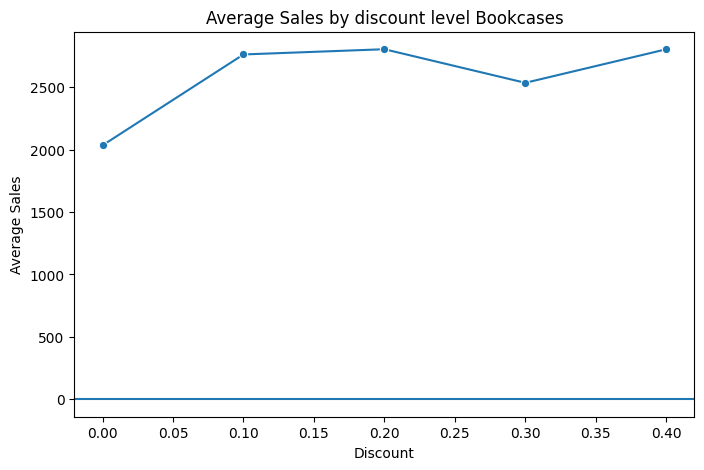

In [61]:
plt.figure(figsize=(8,5))
sns.lineplot(data=discount_sales, x = 'Discount', y = 'Sales', marker='o')
plt.title('Average Sales by discount level Bookcases')
plt.xlabel('Discount')
plt.ylabel('Average Sales')
plt.axhline(0)
plt.savefig('sales_discount.png')
plt.show()

### Demand Impact of Discount

The analysis shows that increasing discount levels does not significantly increase sales for Bookcases.

Sales remain relatively stable across different discount levels, and in some cases, higher discounts even correspond to lower average sales.

This indicates that discounting is not effectively improving customer demand.


## Final Conclusion

The Furniture category underperforms primarily due to the Bookcases sub-category.

Detailed analysis reveals:

- Bookcases have the lowest profit margin
- They receive relatively higher discounts
- Some orders are loss-making
- Higher discounts reduce profit but do not significantly increase sales

Therefore, the core issue is not low demand but an ineffective discount strategy. The company is sacrificing profitability without gaining meaningful sales growth.


## Business Recommendation

Instead of increasing discounts, the company should focus on:

- Limiting discount levels (ideally below 25%)
- Improving product positioning
- Bundling Bookcases with complementary products
- Optimizing pricing strategy

Controlling discounts alone could significantly improve overall Furniture profitability without requiring additional sales volume.
